In [228]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')

In [229]:
def simulate_cars(tp1 = 260, 
                  tp2 = 260, 
                  tp3 = 150, 
                  wr_cm = None,  
                  T2 = None, 
                  A = None, 
                  phi = None, 
                  tmin = -2000, 
                  tmax = 10000, 
                  floor=10):
        #if nuR is None: nuR = np.array([1450, 1590])
        if T2  is None: T2  = np.array([1000, 1000])
        if A   is None: A   = np.array([3, 3])
        if phi is None: phi = np.array([0, 0])
        if wr_cm is None: wr_cm = np.array([10, 40])

        # Now safe to mutate A — it's a fresh array every call
        A = A.copy()  # extra safety if caller passes their own array
        for i in range(len(A)):
            if A[i] != 0:
                A[i] = 10**A[i]
        step0=5; step1=5; step2=5
        FS_TO_S = 1e-15  # conversion factor from femtoseconds to seconds
        c = 299792458  # speed of light in m/s
        # Gaussian pump × Stokes joint spectral amplitude exponent
        a12 = -2 * np.log(2) * (1/tp1**2 + 1/tp2**2)
        #wt = 2 * np.pi * c * (1/wl1 - 1/wl2) * 1e9 * FS_TO_S  # Raman frequency in rad/fs
        # Oscillator decay constants (complex): −1/T₂ − iΔω
        #wR = 2 * np.pi * nuR * c * 100 * FS_TO_S             # [rad/fs]
        #wr = (wt - wR)
        wr = wr_cm * 2 * np.pi * c * 100 * FS_TO_S             # [rad/fs]
        b = -1.0 / T2 - 1j * wr    # shape (n_modes,)

        # --- Inner integral: nuclear response Q(t) ---
        lim = 5 * tp1
        ts  = np.arange(-lim, lim, step0)       # integration variable
        t1  = np.arange(tmin, tmax, step1)

        pump_stokes_env = np.exp(a12 * ts**2)    # pump × Stokes envelope (precomputed)

        Q = np.zeros(len(t1), dtype=complex)

        for j, t in enumerate(t1):
            # Heaviside step function (vectorised via clipping)
            if t <= -lim:
                hs = np.zeros(len(ts))
            elif t >= lim:
                hs = np.ones(len(ts))
            else:
                p = int(round((t + lim) / step0))
                hs = np.zeros(len(ts))
                hs[:p] = 1.0

            # Sum oscillator contributions: shape (n_modes, n_ts) → scalar
            osc = np.zeros_like(ts, dtype=complex)
            for i in range(len(T2)):
                 osc += 1e20 * A[i] * np.exp(b[i] * (t - ts)) * np.exp(1j * phi[i])

            F1   = hs * osc * pump_stokes_env
            Q[j] = step0 * np.trapezoid(F1)

        Q_sq = (FS_TO_S * np.abs(Q)) ** 2

        # --- Outer convolution with probe pulse ---
        a3 = -4 * np.log(2) / tp3**2

        td     = np.arange(tmin + 5*tp3, tmax - 5*tp3 + step2, step2)
        signal = np.empty(len(td))

        for j, t_d in enumerate(td):
            I3       = np.sqrt(-a3 / np.pi) * np.exp(a3 * (t1 - t_d)**2)
            signal[j] = FS_TO_S * step2 * np.trapezoid(Q_sq * I3) + floor
        return td, signal

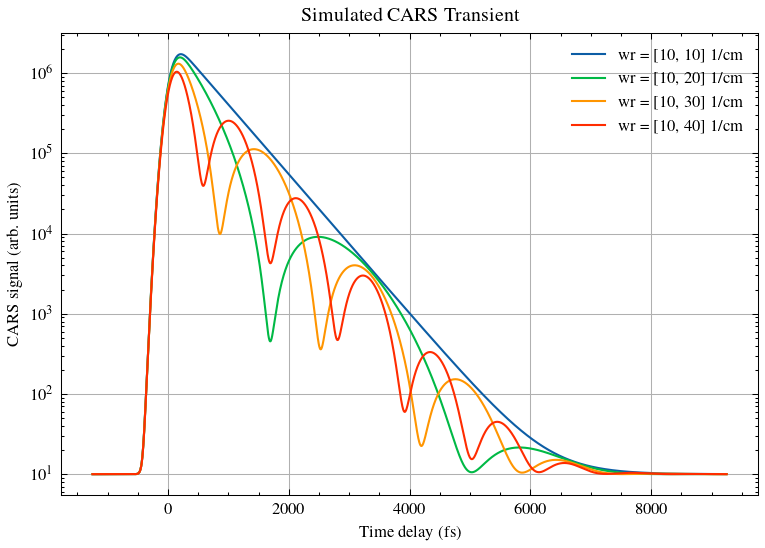

In [230]:
fig = plt.figure(figsize=(6,4), dpi = 150)
arr = [[10,10], [10, 20], [10, 30], [10, 40]]
for val in arr:
    td, signal = simulate_cars(wr_cm=np.array(val))
    plt.plot(td, signal, label=f'wr = {val} 1/cm')
plt.xlabel('Time delay (fs)')
plt.ylabel('CARS signal (arb. units)')
plt.yscale('log')
plt.title('Simulated CARS Transient')
plt.legend()
plt.grid()
plt.show()

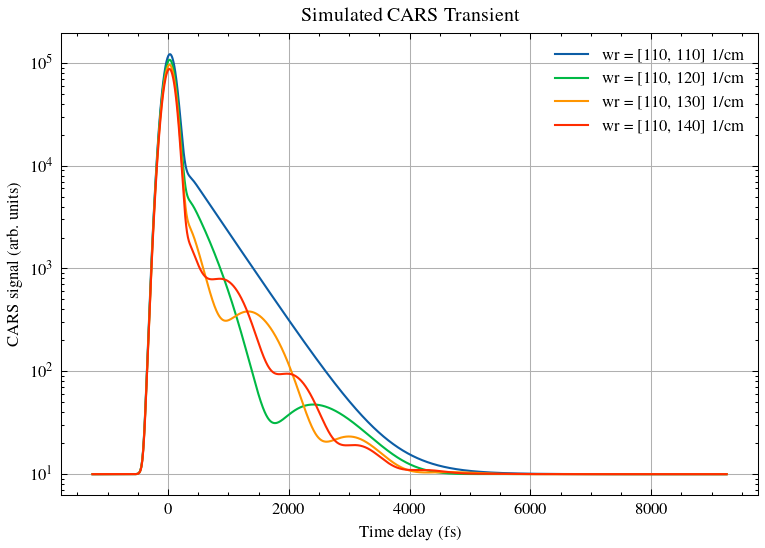

In [235]:
fig = plt.figure(figsize=(6,4), dpi = 150)
arr = [[110,110], [110, 120], [110, 130], [110, 140]]
for val in arr:
    td, signal = simulate_cars(wr_cm=np.array(val))
    plt.plot(td, signal, label=f'wr = {val} 1/cm')
plt.xlabel('Time delay (fs)')
plt.ylabel('CARS signal (arb. units)')
plt.yscale('log')
plt.title('Simulated CARS Transient')
plt.legend()
plt.grid()
plt.show()

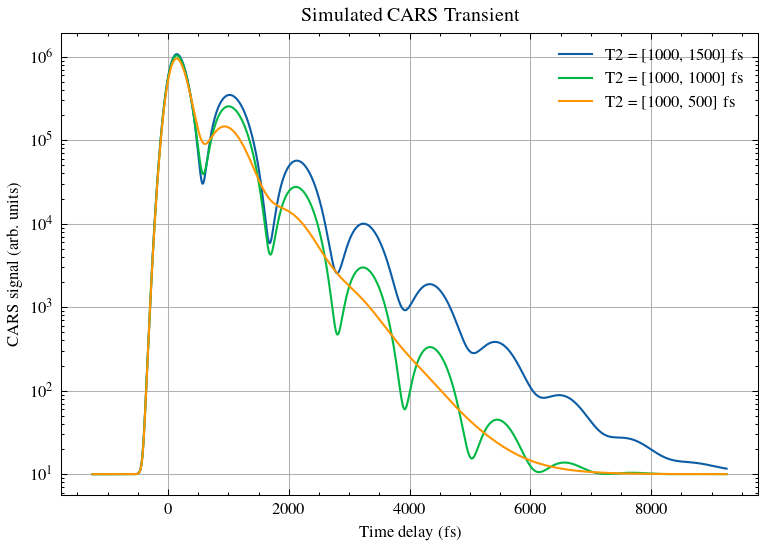

In [232]:
fig = plt.figure(figsize=(6,4), dpi = 150)
arr = [[1000,1500], [1000, 1000], [1000, 500]]
for val in arr:
    td, signal = simulate_cars(T2=np.array(val))
    plt.plot(td, signal, label=f'T2 = {val} fs')
plt.xlabel('Time delay (fs)')
plt.ylabel('CARS signal (arb. units)')
plt.yscale('log')
plt.title('Simulated CARS Transient')
plt.legend()
plt.grid()
plt.show()

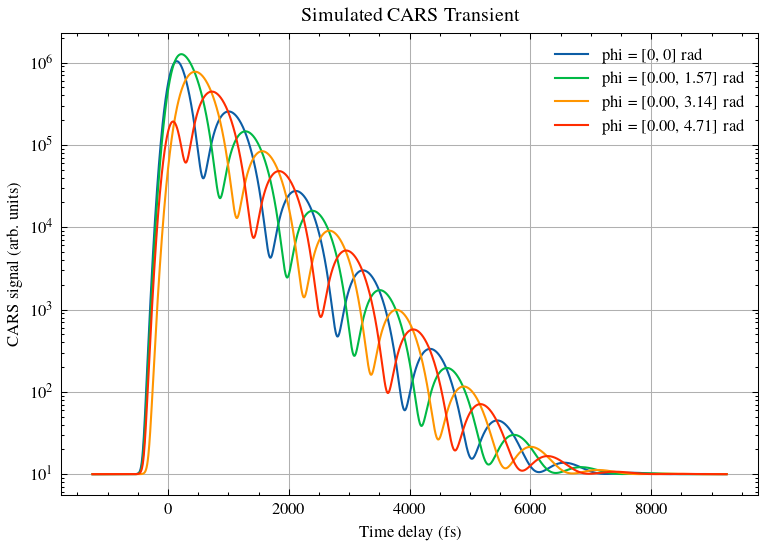

In [233]:
fig = plt.figure(figsize=(6,4), dpi = 150)
arr = [[0, 0], [0, 2*np.pi/4], [0, np.pi], [0, 6*np.pi/4]]
for val in arr:
    td, signal = simulate_cars(phi=np.array(val))
    plt.plot(td, signal, label=f'phi = {np.array2string(np.array(val), precision=2, floatmode="fixed", separator=", ")} rad')
plt.xlabel('Time delay (fs)')
plt.ylabel('CARS signal (arb. units)')
plt.yscale('log')
plt.title('Simulated CARS Transient')
plt.legend()
plt.grid()
plt.show()

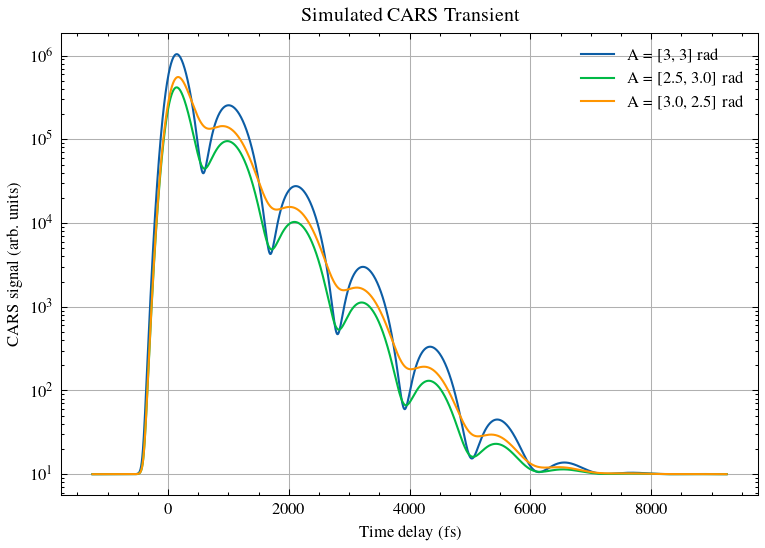

In [234]:
fig = plt.figure(figsize=(6,4), dpi = 150)
arr = [[3,3], [2.5,3], [3,2.5]]
for val in arr:
    td, signal = simulate_cars(A=np.array(val))
    plt.plot(td, signal, label=f'A = {np.array2string(np.array(val), precision=1, floatmode="fixed", separator=", " )} rad')
plt.xlabel('Time delay (fs)')
plt.ylabel('CARS signal (arb. units)')
plt.yscale('log')
plt.title('Simulated CARS Transient')
plt.legend()
plt.grid()
plt.show()